## 0. Environment setup

Required packages (install with `pip install ...` if missing):

- `scikit-learn` — PCA, LDA, LSA (note: install as `scikit-learn`, import as `sklearn`)
- `scipy` — statistical tests used by factor analysis
- `factor_analyzer` — latent factor analysis (KMO, Bartlett's test, FactorAnalyzer)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy
import importlib.metadata

print("sklearn", sklearn.__version__)
print("scipy", scipy.__version__)
print("factor_analyzer", importlib.metadata.version("factor_analyzer"))
print("pandas", pd.__version__, "| numpy", np.__version__)

sklearn 1.9.1
scipy 1.18.1
factor_analyzer 0.5.1
pandas 3.0.6 | numpy 2.5.3


## 1. Principal Component Analysis (PCA)

PCA finds orthogonal directions (principal components) of maximum variance in the data and
projects the data onto the first few of them. It is **unsupervised** — class labels are not used.

We use the classic **Iris** dataset (150 samples, 4 features, 3 classes).

**Steps**

1. Standardize the features (PCA is scale-sensitive).
2. Fit `PCA` and inspect the explained variance ratio.
3. Choose the number of components (scree plot / cumulative variance).
4. Project to 2D and visualize.

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
target_names = iris.target_names
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
pd.DataFrame(X_scaled, columns=X.columns).describe().loc[["mean", "std"]]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00


In [4]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(pca.n_components_)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
})
explained

,component,explained_variance_ratio,cumulative
0,PC1,0.729624,0.729624
1,PC2,0.228508,0.958132
2,PC3,0.036689,0.994821
3,PC4,0.005179,1.000000


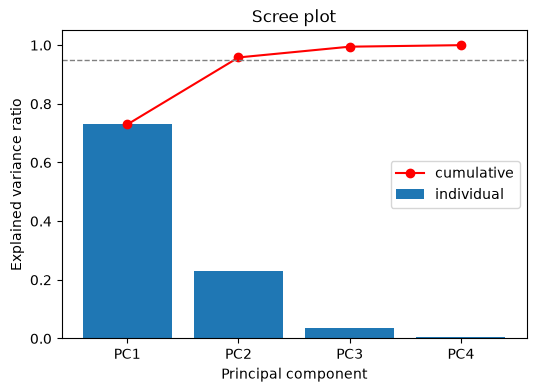

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(explained["component"], explained["explained_variance_ratio"], label="individual")
ax.plot(explained["component"], explained["cumulative"], "o-", color="red", label="cumulative")
ax.axhline(0.95, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Scree plot")
ax.legend()
plt.show()

**Observation**: PC1 alone explains ~73% of the variance; PC1 + PC2 together explain ~96%,
so 2 components are enough to represent the 4-dimensional data.

The **loadings** (component weights) show how each original feature contributes:

In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)
loadings

,PC1,PC2,PC3,PC4
sepal length (cm),0.521066,0.377418,0.719566,-0.261286
sepal width (cm),-0.269347,0.923296,-0.244382,0.123510
petal length (cm),0.580413,0.024492,-0.142126,0.801449
petal width (cm),0.564857,0.066942,-0.634273,-0.523597


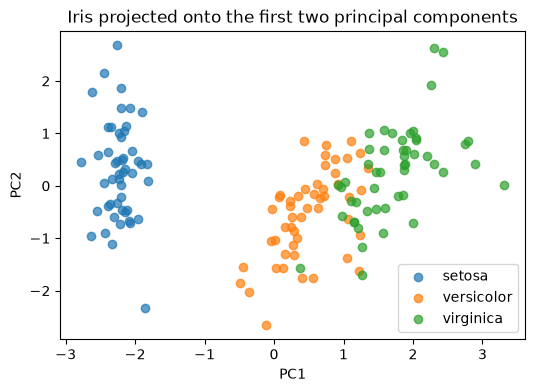

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for cls, name in enumerate(target_names):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Iris projected onto the first two principal components")
ax.legend()
plt.show()

**Observation**: *setosa* is clearly separated from the other two species already in the
first two principal components.

## 2. Latent Factor Analysis (LFA)

*Following the [DataCamp factor analysis tutorial](https://www.datacamp.com/community/tutorials/introduction-factor-analysis).*

Factor analysis is a linear statistical model that explains the variance among observed
variables in terms of a smaller number of unobserved **latent factors**. Observed variables
are modeled as linear combinations of factors plus error terms — the reverse direction of PCA.

**Terminology**

- **Factor loadings** — correlation between each observed variable and each factor
- **Eigenvalues** — variance explained by each factor (Kaiser criterion: keep eigenvalue > 1)
- **Communalities** — sum of squared loadings per variable (common variance, 0–1)
- **Rotation** (e.g. varimax) — redistributes loadings for a clearer, interpretable pattern

### 2.1 Data: BFI personality assessment

The BFI dataset (`bfi.csv`, from the [Rdatasets collection](https://vincentarelbundock.github.io/Rdatasets/datasets.html),
R package `psych`) contains 2,800 responses to 25 personality items on a 6-point scale
(1 = Very Inaccurate … 6 = Very Accurate), designed around the "Big Five" traits:

| Prefix | Trait | Prefix | Trait |
|---|---|---|---|
| A | Agreeableness | N | Neuroticism |
| C | Conscientiousness | O | Openness |
| E | Extraversion | | |

In [8]:
df = pd.read_csv("bfi.csv", index_col=0)

# Dropping unnecessary columns
df = df.drop(["gender", "education", "age"], axis=1)

# Dropping missing values rows
df = df.dropna()

df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 2436 entries, 61617 to 67560
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      2436 non-null   float64
 1   A2      2436 non-null   float64
 2   A3      2436 non-null   float64
 3   A4      2436 non-null   float64
 4   A5      2436 non-null   float64
 5   C1      2436 non-null   float64
 6   C2      2436 non-null   float64
 7   C3      2436 non-null   float64
 8   C4      2436 non-null   float64
 9   C5      2436 non-null   float64
 10  E1      2436 non-null   float64
 11  E2      2436 non-null   float64
 12  E3      2436 non-null   float64
 13  E4      2436 non-null   float64
 14  E5      2436 non-null   float64
 15  N1      2436 non-null   float64
 16  N2      2436 non-null   float64
 17  N3      2436 non-null   float64
 18  N4      2436 non-null   float64
 19  N5      2436 non-null   float64
 20  O1      2436 non-null   float64
 21  O2      2436 non-null   int64  
 22  O3      243

,A1,A2,A3,A4,A5,C1,C2,C3,C4,C5,...,N1,N2,N3,N4,N5,O1,O2,O3,O4,O5
rownames,,,,,,,,,,,,,,,,,,,,,
61617,2.0,4.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,4.0,...,3.0,4.0,2.0,2.0,3.0,3.0,6,3.0,4.0,3.0
61618,2.0,4.0,5.0,2.0,5.0,5.0,4.0,4.0,3.0,4.0,...,3.0,3.0,3.0,5.0,5.0,4.0,2,4.0,3.0,3.0
61620,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,2.0,5.0,...,4.0,5.0,4.0,2.0,3.0,4.0,2,5.0,5.0,2.0
61621,4.0,4.0,6.0,5.0,5.0,4.0,4.0,3.0,5.0,5.0,...,2.0,5.0,2.0,4.0,1.0,3.0,3,4.0,3.0,5.0
61622,2.0,3.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0,2.0,...,2.0,3.0,4.0,4.0,3.0,3.0,3,4.0,3.0,3.0


### 2.2 Adequacy tests

Before factor analysis, evaluate the "factorability" of the dataset:

- **Bartlett's test of sphericity** — tests the observed correlation matrix against the
  identity matrix; if statistically insignificant, factor analysis should not be used
- **Kaiser-Meyer-Olkin (KMO)** — measures suitability for factor analysis; values below
  0.6 are considered inadequate

In [9]:
# factor_analyzer 0.5.1 predates scikit-learn 1.8, which renamed the
# check_array keyword force_all_finite -> ensure_all_finite. Shim it:
import factor_analyzer.factor_analyzer as _faa
from sklearn.utils import check_array as _orig_check_array

def _check_array_compat(*args, **kwargs):
    if "force_all_finite" in kwargs:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return _orig_check_array(*args, **kwargs)

_faa.check_array = _check_array_compat

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

chi_square_value, p_value = calculate_bartlett_sphericity(df)
chi_square_value, p_value

(np.float64(18146.065577234796), np.float64(0.0))

**Observation**: the p-value is 0, so the test is statistically significant — the
observed correlation matrix is not an identity matrix, and the variables do intercorrelate.

In [10]:
kmo_all, kmo_model = calculate_kmo(df)
kmo_model

np.float64(0.8486452309468389)

**Observation**: the overall KMO is ~0.85, which is excellent (well above 0.6), so we
can proceed with factor analysis.

### 2.3 Choosing the number of factors

Using the **Kaiser criterion** (eigenvalue > 1) and a **scree plot**:

In [11]:
from factor_analyzer import FactorAnalyzer

# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(n_factors=25, rotation=None)
fa.fit(df)

# Check eigenvalues
ev, v = fa.get_eigenvalues()
pd.DataFrame({"factor": range(1, len(ev) + 1), "eigenvalue": ev})

,factor,eigenvalue
0,1,5.134311
1,2,2.751887
2,3,2.142702
3,4,1.852328
4,5,1.548163
5,6,1.073582
6,7,0.839539
7,8,0.799206
8,9,0.718989
9,10,0.688089


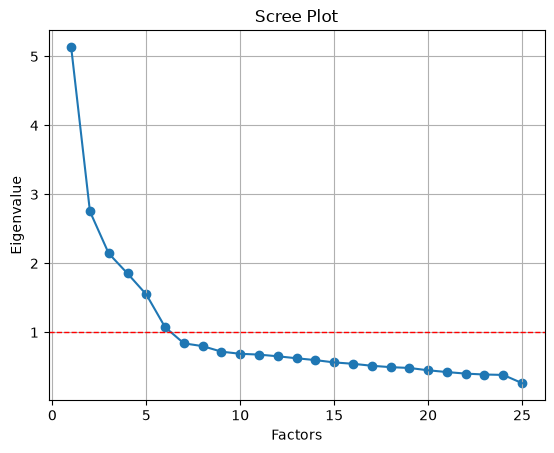

In [12]:
plt.scatter(range(1, df.shape[1] + 1), ev)
plt.plot(range(1, df.shape[1] + 1), ev)
plt.title("Scree Plot")
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
plt.axhline(1, color="red", linestyle="--", linewidth=1)
plt.grid()
plt.show()

**Observation**: only 6 factors have eigenvalues greater than 1, so the Kaiser criterion
suggests 6 factors.

### 2.4 Factor analysis with varimax rotation

In [13]:
fa = FactorAnalyzer(n_factors=6, rotation="varimax")
fa.fit(df)
loadings6 = pd.DataFrame(fa.loadings_, index=df.columns,
                         columns=[f"Factor{i}" for i in range(1, 7)])
loadings6

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6
A1,0.095220,0.040783,0.048734,-0.530987,-0.113057,0.161216
A2,0.033131,0.235538,0.133714,0.661141,0.063734,-0.006244
A3,-0.009621,0.343008,0.121353,0.605933,0.033990,0.160106
A4,-0.081518,0.219717,0.235140,0.404594,-0.125338,0.086356
A5,-0.149616,0.414458,0.106382,0.469698,0.030977,0.236519
C1,-0.004358,0.077248,0.554582,0.007511,0.190124,0.095035
C2,0.068330,0.038370,0.674545,0.057055,0.087593,0.152775
C3,-0.039994,0.031867,0.551164,0.101282,-0.011338,0.008996
C4,0.216283,-0.066241,-0.638475,-0.102617,-0.143846,0.318359
C5,0.284187,-0.180812,-0.544838,-0.059955,0.025837,0.132423


**Interpreting the loadings** (high |loading| per factor):

- Factor 1 — high loadings for E1–E5 → **Extraversion**
- Factor 2 — high loadings for N1–N5 → **Neuroticism**
- Factor 3 — high loadings for C1–C5 → **Conscientiousness**
- Factor 4 — high loadings for O1–O5 → **Openness**
- Factor 5 — high loadings for A1–A5 → **Agreeableness**
- Factor 6 — no high loadings for any variable and is not easily interpretable

So we drop Factor 6 and re-run with **5 factors** — neatly recovering the Big Five:

In [14]:
fa5 = FactorAnalyzer(n_factors=5, rotation="varimax")
fa5.fit(df)
loadings5 = pd.DataFrame(fa5.loadings_, index=df.columns,
                         columns=[f"Factor{i}" for i in range(1, 6)])
loadings5

,Factor1,Factor2,Factor3,Factor4,Factor5
A1,0.111126,0.040465,0.022798,-0.428166,-0.077931
A2,0.029588,0.213716,0.139037,0.626946,0.062139
A3,0.009357,0.317848,0.109331,0.650743,0.056196
A4,-0.066476,0.204566,0.230584,0.435624,-0.112700
A5,-0.122113,0.393034,0.087869,0.537087,0.066708
C1,0.010416,0.070184,0.545824,0.038878,0.209584
C2,0.089574,0.033270,0.648731,0.102782,0.115434
C3,-0.030855,0.023907,0.557036,0.111578,-0.005183
C4,0.240410,-0.064984,-0.633806,-0.037498,-0.107535
C5,0.290318,-0.176395,-0.562467,-0.047525,0.036822


In [15]:
# Get variance of each factor
variance = pd.DataFrame(
    fa5.get_factor_variance(),
    index=["SS Loadings", "Proportion Var", "Cumulative Var"],
    columns=[f"Factor{i}" for i in range(1, 6)],
)
variance

,Factor1,Factor2,Factor3,Factor4,Factor5
SS Loadings,2.709633,2.473090,2.041106,1.844498,1.522153
Proportion Var,0.108385,0.098924,0.081644,0.073780,0.060886
Cumulative Var,0.108385,0.207309,0.288953,0.362733,0.423619


**Observation**: the 5 factors together explain ~42% of the total cumulative variance.

**Pros and cons**: factor analysis reduces many observed variables into a few interpretable
latent ones and reveals hidden associations; but its interpretation can be debatable —
more than one interpretation may fit the same factors, and naming factors requires domain
knowledge.

## 3. Linear Discriminant Analysis (LDA)

*Following [Machine Learning Mastery — LDA with Python](https://machinelearningmastery.com/linear-discriminant-analysis-with-python/).*

LDA is a **supervised** linear classification algorithm. It computes summary statistics
(mean, variance) of the input features per class and classifies a new example by the class
with the highest conditional probability. LDA assumes numeric, roughly Gaussian features
with equal variance — standardizing first is good practice.

Two uses of LDA:

1. as a **dimensionality reduction** method (project onto at most *n_classes − 1* discriminants)
2. as a **classifier**

### 3.1 LDA for dimensionality reduction (Iris)

Explained variance ratio per discriminant: [0.9912126 0.0087874]


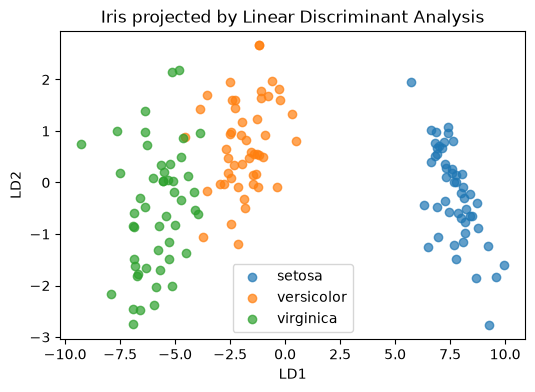

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("Explained variance ratio per discriminant:", lda.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(6, 4))
for cls, name in enumerate(target_names):
    mask = y == cls
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], label=name, alpha=0.7)
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_title("Iris projected by Linear Discriminant Analysis")
ax.legend()
plt.show()

Because LDA uses the class labels, all three species are well separated in 2D —
compare with the unsupervised PCA plot above, where *versicolor* and *virginica* overlap.

### 3.2 LDA as a classifier (synthetic dataset)

Following the reference tutorial, we create a synthetic classification dataset with
1,000 examples and 10 input variables, then evaluate LDA with **repeated stratified
k-fold cross-validation** (10 folds, 3 repeats):

In [17]:
from numpy import mean, std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

# define dataset
X_syn, y_syn = make_classification(n_samples=1000, n_features=10, n_informative=10,
                                   n_redundant=0, random_state=1)
print(X_syn.shape, y_syn.shape)

# define model
model = LinearDiscriminantAnalysis()

# define model evaluation method
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# evaluate model
scores = cross_val_score(model, X_syn, y_syn, scoring="accuracy", cv=cv, n_jobs=-1)

# summarize result
print("Mean Accuracy: %.3f (%.3f)" % (mean(scores), std(scores)))

(1000, 10) (1000,)
Mean Accuracy: 0.893 (0.033)


In [18]:
# fit the final model on all available data and make a prediction for one new row
model.fit(X_syn, y_syn)
row = [0.12777556, -3.64400522, -2.23268854, -1.82114386, 1.75466361,
       0.1243966, 1.03397657, 2.35822076, 1.01001752, 0.56768485]
yhat = model.predict([row])
print("Predicted Class: %d" % yhat[0])

Predicted Class: 1


### 3.3 Tuning LDA hyperparameters

An important hyperparameter is the **solver** (`svd` by default; `lsqr` and `eigen` support
**shrinkage**, a regularization penalty between 0 and 1). We tune both with `GridSearchCV`:

In [19]:
from sklearn.model_selection import GridSearchCV

# tune the solver
grid = {"solver": ["svd", "lsqr", "eigen"]}
search = GridSearchCV(LinearDiscriminantAnalysis(), grid,
                      scoring="accuracy", cv=cv, n_jobs=-1)
results = search.fit(X_syn, y_syn)
print("Mean Accuracy: %.3f" % results.best_score_)
print("Config: %s" % results.best_params_)

Mean Accuracy: 0.893
Config: {'solver': 'svd'}


In [20]:
# tune shrinkage (requires a solver that supports it, e.g. lsqr)
grid = {"shrinkage": np.arange(0, 1, 0.01)}
search = GridSearchCV(LinearDiscriminantAnalysis(solver="lsqr"), grid,
                      scoring="accuracy", cv=cv, n_jobs=-1)
results = search.fit(X_syn, y_syn)
print("Mean Accuracy: %.3f" % results.best_score_)
print("Config: %s" % results.best_params_)

Mean Accuracy: 0.894
Config: {'shrinkage': np.float64(0.02)}


## 4. Optional — Latent Semantic Analysis (LSA)

*Following the [Duke bios-823 SVD notes](https://people.duke.edu/~ccc14/bios-823-2018/Z05_SVD.html).*

LSA applies truncated SVD to a term-document matrix to uncover latent "topics" in text.
With rank $k$, the matrix $M$ is approximated as $M' = U_k \Sigma_k V_k^T$.

### 4.1 Classic example: truncated SVD of a term-frequency matrix

Given this term-frequency matrix (12 terms × 9 documents), reconstruct it with $k = 2$:

In [21]:
M = np.array([[1, 0, 0, 1, 0, 0, 0, 0, 0],
              [1, 0, 1, 0, 0, 0, 0, 0, 0],
              [1, 1, 0, 0, 0, 0, 0, 0, 0],
              [0, 1, 1, 0, 1, 0, 0, 0, 0],
              [0, 1, 1, 2, 0, 0, 0, 0, 0],
              [0, 1, 0, 0, 1, 0, 0, 0, 0],
              [0, 1, 0, 0, 1, 0, 0, 0, 0],
              [0, 0, 1, 1, 0, 0, 0, 0, 0],
              [0, 1, 0, 0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 1, 1, 1, 0],
              [0, 0, 0, 0, 0, 0, 1, 1, 1],
              [0, 0, 0, 0, 0, 0, 0, 1, 1]])

U, s, Vt = np.linalg.svd(M, full_matrices=False)

k = 2
M_prime = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
np.set_printoptions(precision=2, suppress=True)
print("Reconstructed matrix M' with k =", k)
print(M_prime)

Reconstructed matrix M' with k = 2
[[ 0.16  0.4   0.38  0.47  0.18 -0.05 -0.12 -0.16 -0.09]
 [ 0.14  0.37  0.33  0.4   0.16 -0.03 -0.07 -0.1  -0.04]
 [ 0.15  0.51  0.36  0.41  0.24  0.02  0.06  0.09  0.12]
 [ 0.26  0.84  0.61  0.7   0.39  0.03  0.08  0.12  0.19]
 [ 0.45  1.23  1.05  1.27  0.56 -0.07 -0.15 -0.21 -0.05]
 [ 0.16  0.58  0.38  0.42  0.28  0.06  0.13  0.19  0.22]
 [ 0.16  0.58  0.38  0.42  0.28  0.06  0.13  0.19  0.22]
 [ 0.22  0.55  0.51  0.63  0.24 -0.07 -0.14 -0.2  -0.11]
 [ 0.1   0.53  0.23  0.21  0.27  0.14  0.31  0.44  0.42]
 [-0.06  0.23 -0.14 -0.27  0.14  0.24  0.55  0.77  0.66]
 [-0.06  0.34 -0.15 -0.3   0.2   0.31  0.69  0.98  0.85]
 [-0.04  0.25 -0.1  -0.21  0.15  0.22  0.5   0.71  0.62]]


**Observation**: the rank-2 reconstruction smooths the raw counts — zeros inside a topic
block become positive (e.g. terms that never co-occurred literally still get related through
the latent topics), which is exactly the "semantic" effect LSA exploits.

### 4.2 LSA on a small text corpus with scikit-learn

In practice we build the term-document matrix with TF-IDF and use `TruncatedSVD`. Here is a
tiny corpus about three themes (sports, tech, food):

In [22]:
corpus = [
    "the team won the football match after scoring a goal",
    "basketball players train hard for the championship game",
    "the striker scored two goals in the league match",
    "the new smartphone has a faster processor and more memory",
    "software engineers write code and debug computer programs",
    "the laptop battery and processor make computing faster",
    "the chef cooked pasta with tomato sauce and cheese",
    "baking bread requires flour, yeast and a hot oven",
    "the restaurant serves delicious pizza and fresh salad",
]

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(stop_words="english")
X_text = tfidf.fit_transform(corpus)
print("Term-document matrix shape:", X_text.shape)

lsa = TruncatedSVD(n_components=2, random_state=42)
X_lsa = lsa.fit_transform(X_text)

terms = np.array(tfidf.get_feature_names_out())
for i, component in enumerate(lsa.components_):
    top = terms[np.argsort(component)[::-1][:6]]
    print(f"Topic {i+1}: {', '.join(top)}")

Term-document matrix shape: (9, 51)
Topic 1: faster, processor, new, smartphone, memory, computing
Topic 2: match, striker, goals, scored, league, won


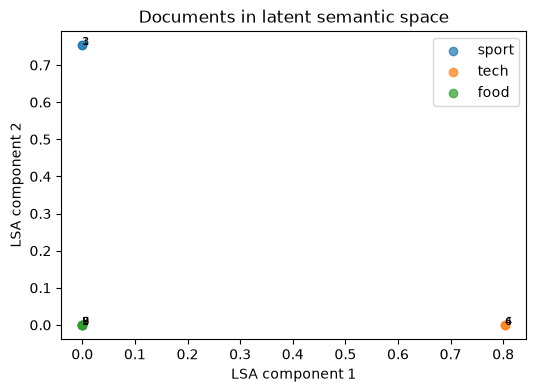

In [23]:
labels = ["sport"] * 3 + ["tech"] * 3 + ["food"] * 3

fig, ax = plt.subplots(figsize=(6, 4))
for lab in ["sport", "tech", "food"]:
    mask = np.array(labels) == lab
    ax.scatter(X_lsa[mask, 0], X_lsa[mask, 1], label=lab, alpha=0.7)
for i, doc in enumerate(corpus):
    ax.annotate(str(i + 1), (X_lsa[i, 0], X_lsa[i, 1]), fontsize=8)
ax.set_xlabel("LSA component 1")
ax.set_ylabel("LSA component 2")
ax.set_title("Documents in latent semantic space")
ax.legend()
plt.show()

**Observation**: documents about the same theme cluster together in the 2D latent space,
and the top terms per topic recover the underlying themes.

## Summary

| Method | Supervised? | Input | Use case |
|---|---|---|---|
| PCA | No | numeric features | variance-preserving compression, visualization |
| LFA | No | numeric features | modelling latent constructs behind correlated variables |
| LDA | Yes | numeric features + labels | class-separating projection, classification |
| LSA | No | text (term counts / TF-IDF) | topic extraction from documents |